# Série de Fourier

### Processamento Digital de Sinais
#### Prof. Carlos Aurélio Faria Rocha
##### Aluno: Eduardo Borgonha Lopes

In [1]:
import numpy as np 
import matplotlib.pyplot as plt

# 1. Avaliação por Série de Fourier do Sinal Sinusoidal Retificado em Onda Completa

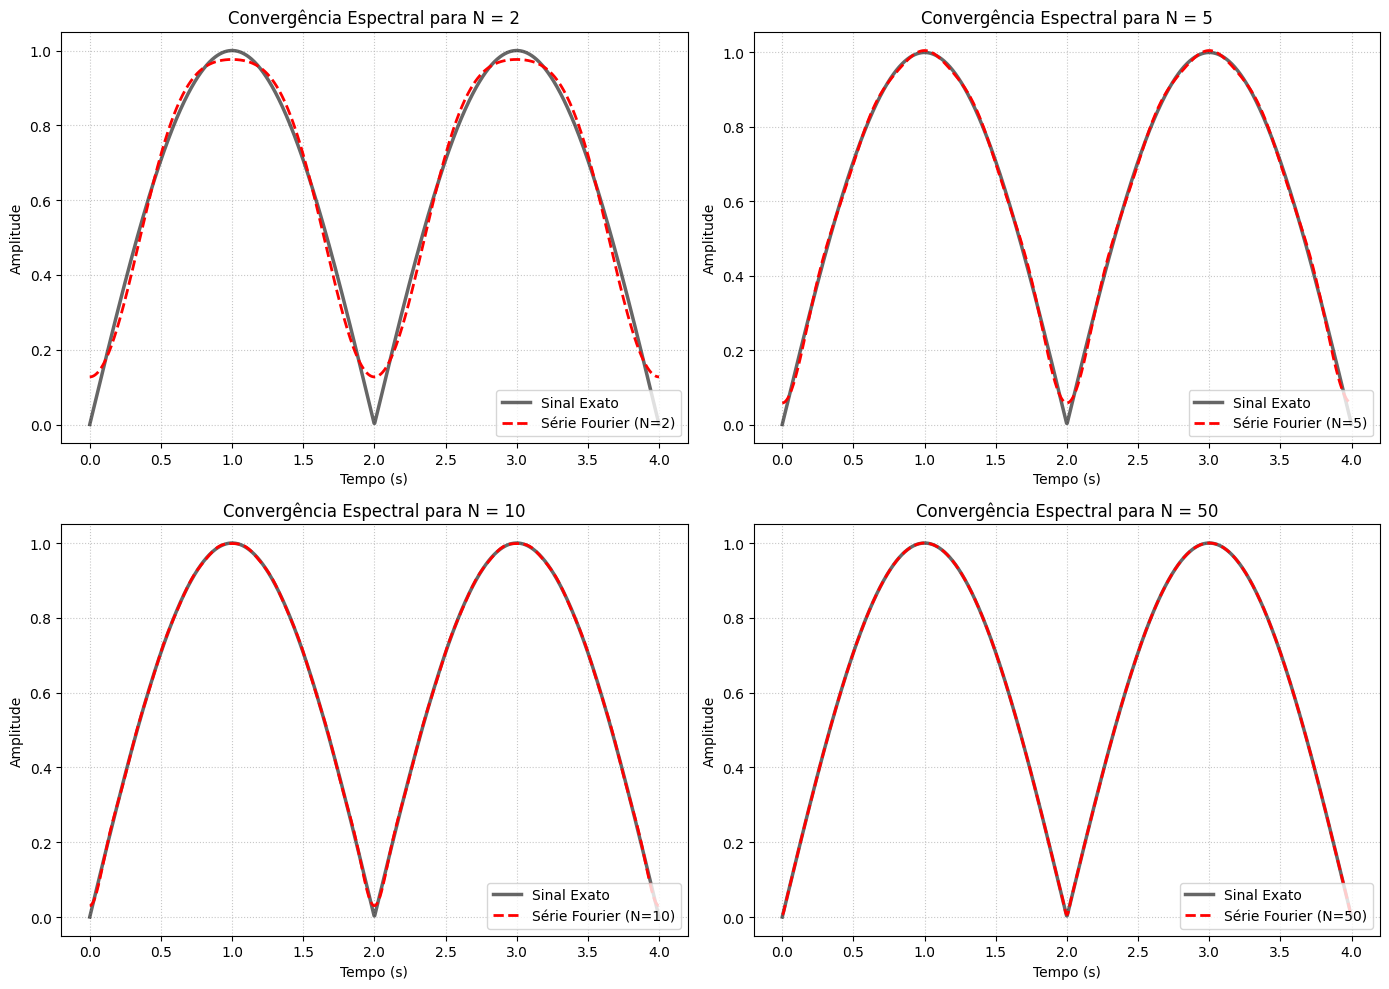

In [2]:
# Parâmetros fundamentais do sinal
T = 2.0
w0 = 2 * np.pi / T
t = np.linspace(0, 2 * T, 1000)

# Função exata (valor absoluto garante a retificação da onda completa)
x_exato = np.abs(np.sin(np.pi * t / 2))

# Vetor contendo as ordens de truncamento exigidas para a análise
ordens_harmonicas = [2, 5, 10, 50]

# Configuração da grade de subgráficos para o Jupyter Notebook
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Laço iterativo para o cômputo e renderização gráfica de cada ordem N
for idx, N in enumerate(ordens_harmonicas):
    # Inicialização do sinal reconstruído com o nível DC (A0)
    xT = np.full_like(t, 2 / np.pi)
    
    # Sintese trigonométrica
    for k in range(1, N + 1):
        # Coeficiente exponencial algébrico derivado analiticamente
        ak = (1 / np.pi) * (2 / (1 - 4 * k**2))
        
        # Conversão para as componentes polares da série trigonométrica
        Ak = 2 * np.abs(ak)
        phi_k = np.angle(ak)
        
        # Superposição linear da harmônica avaliada
        xT += Ak * np.cos(k * w0 * t + phi_k)
        
    # Plotagem geométrica
    ax = axes[idx]
    ax.plot(t, x_exato, 'k', linewidth=2.5, alpha=0.6, label='Sinal Exato')
    ax.plot(t, xT, 'r--', linewidth=2, label=f'Série Fourier (N={N})')
    ax.set_title(f'Convergência Espectral para N = {N}')
    ax.set_xlabel('Tempo (s)')
    ax.set_ylabel('Amplitude')
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend(loc='lower right')

# Otimização do espaçamento residual entre os subgráficos
plt.tight_layout()
plt.show()

=== Avaliação do Erro Quadrático (SEQ) ===
Número de Harmônicas (N) =  2 | SEQ = 2.098987
Número de Harmônicas (N) =  5 | SEQ = 0.201716
Número de Harmônicas (N) = 10 | SEQ = 0.029138
Número de Harmônicas (N) = 50 | SEQ = 0.000266


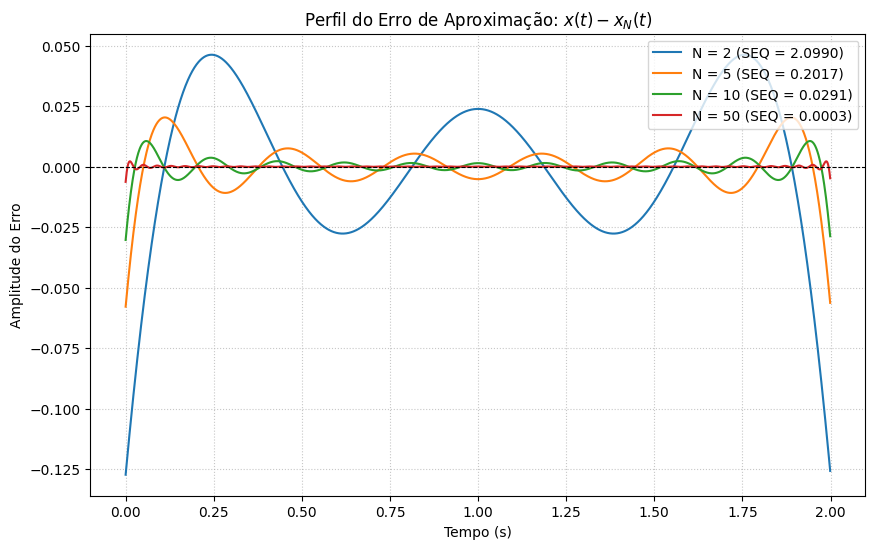

In [3]:
# 1. Parâmetros Fundamentais
T = 2.0
w0 = 2 * np.pi / T
passo = 0.001
t = np.arange(0, T, passo) # Analisando exatamente um período (0 <= t <= T)

# 2. Geração do Sinal Exato
# Utiliza-se o valor absoluto para garantir a retificação da onda senoidal
x_exato = np.abs(np.sin(np.pi * t / 2))

# 3. Definição dos cenários de teste
N_vals = [2, 5, 10, 50]
seq_resultados = [] # Lista para armazenar os resultados

plt.figure(figsize=(10, 6))

# 4. Laço Iterativo para Síntese e Cálculo do Erro
for N in N_vals:
    # A0: Nível DC do sinal
    x_N = np.full_like(t, 2 / np.pi)
    
    # Reconstrução pela Série Trigonométrica
    for k in range(1, N + 1):
        # Utilizando a expressão algébrica deduzida anteriormente
        ak = (1 / np.pi) * (2 / (1 - 4 * k**2))
        
        # Módulo e Fase
        Ak = 2 * np.abs(ak)
        phi_k = np.angle(ak) # Como ak é real e negativo, phi_k = pi
        
        x_N += Ak * np.cos(k * w0 * t + phi_k)
        
    # Equação (3) do roteiro: Cálculo do SEQ discreto
    erro = x_exato - x_N
    seq = np.sum(erro**2)
    seq_resultados.append((N, seq))
    
    # Adicionando a curva de erro ao gráfico
    plt.plot(t, erro, label=f'N = {N} (SEQ = {seq:.4f})')

# 5. Exibição Numérica no Console
print("=== Avaliação do Erro Quadrático (SEQ) ===")
for N, seq in seq_resultados:
    print(f"Número de Harmônicas (N) = {N:2d} | SEQ = {seq:.6f}")

# 6. Renderização Gráfica
plt.title('Perfil do Erro de Aproximação: $x(t) - x_N(t)$')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude do Erro')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

# 2. Avaliação por Série de Fourier da Onda Quadrada

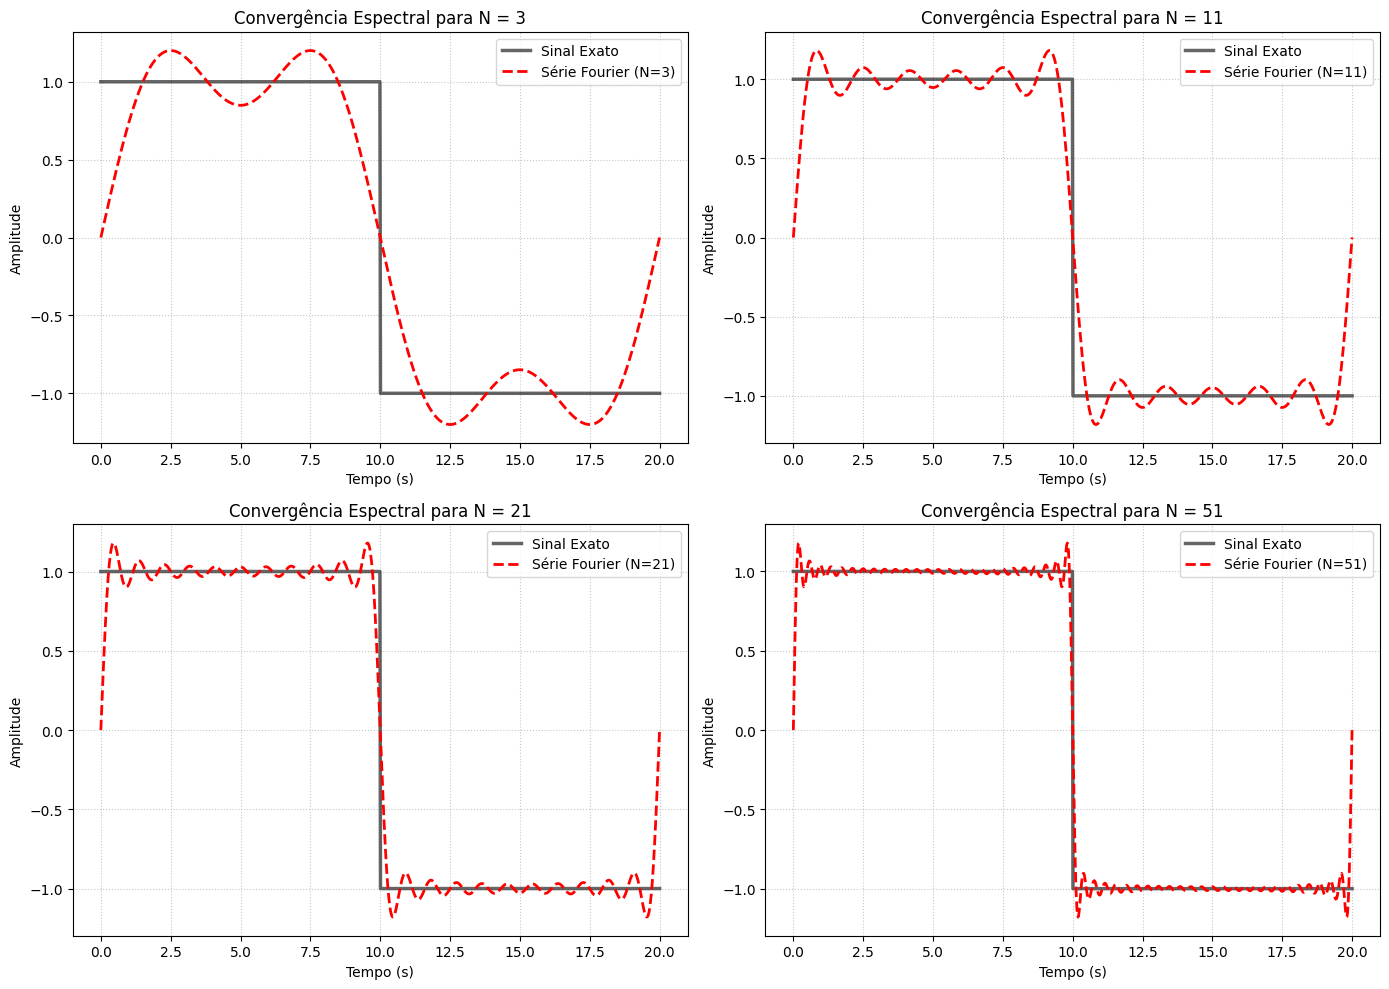

In [7]:
T = 20.0
w0 = 2 * np.pi / T
t = np.linspace(0, T, 1000)

x_exato = np.where(t < T/2, 1, -1)

ordens_harmonicas = [3, 11, 21, 51]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, N in enumerate(ordens_harmonicas):
    xT = np.zeros_like(t, dtype=complex)
    
    for k in range(-N, N + 1):
        if k != 0:
            ak = (1 - np.cos(k * np.pi)) / (1j * k * np.pi)
            xT += ak * np.exp(1j * k * w0 * t)
            
    ax = axes[idx]
    ax.plot(t, x_exato, 'k', linewidth=2.5, alpha=0.6, label='Sinal Exato')
    ax.plot(t, xT.real, 'r--', linewidth=2, label=f'Série Fourier (N={N})')
    ax.set_title(f'Convergência Espectral para N = {N}')
    ax.set_xlabel('Tempo (s)')
    ax.set_ylabel('Amplitude')
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

# 3. Filtragem da Onda Quadrada pelo Circuito RC

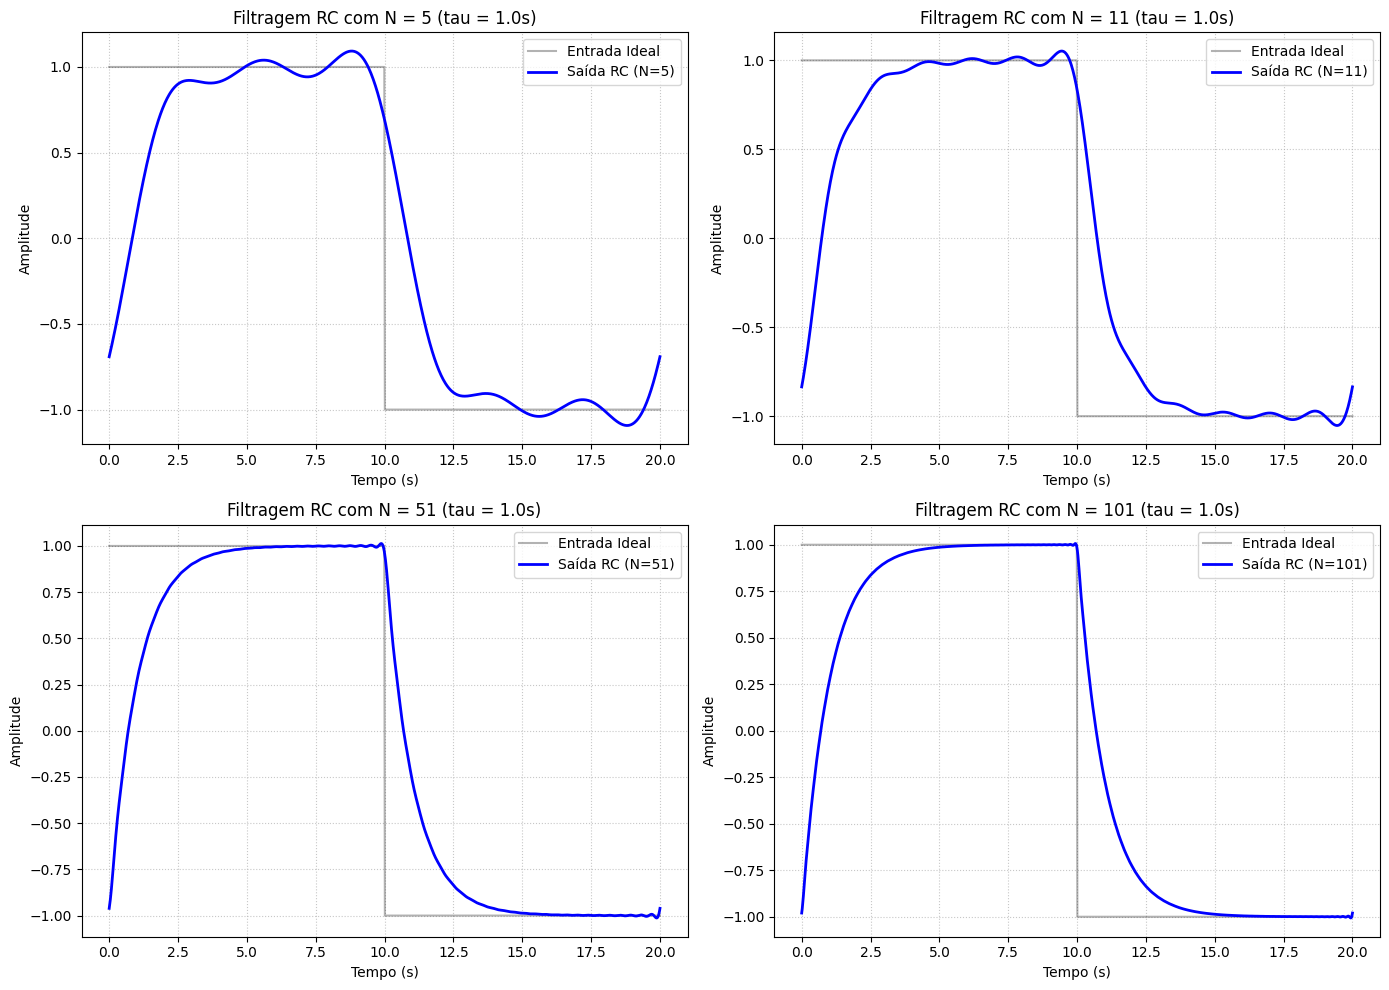

In [9]:
T = 20.0
w0 = 2 * np.pi / T
t = np.linspace(0, T, 1000)

x_exato = np.where(t < T/2, 1, -1)

ordens_harmonicas = [5, 11, 51, 101]
tau = 1.0 

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, N in enumerate(ordens_harmonicas):
    yT = np.zeros_like(t, dtype=complex)
    
    for k in range(-N, N + 1):
        if k != 0:
            H_k = 1 / (1 + 1j * k * w0 * tau)
            
            ak = (1 - np.cos(k * np.pi)) / (1j * k * np.pi)
            
            ck = H_k * ak
            yT += ck * np.exp(1j * k * w0 * t)
            
    ax = axes[idx]
    ax.plot(t, x_exato, 'k', linewidth=1.5, alpha=0.3, label='Entrada Ideal')
    ax.plot(t, yT.real, 'b', linewidth=2, label=f'Saída RC (N={N})')
    ax.set_title(f'Filtragem RC com N = {N} (tau = {tau}s)')
    ax.set_xlabel('Tempo (s)')
    ax.set_ylabel('Amplitude')
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()